## 📦 1. 环境准备与数据加载

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 通过 rc 参数设置中文字体
sns.set_theme(
    style="whitegrid",
    font_scale=1.1,
    rc={
        "font.sans-serif": ["Microsoft YaHei"],
        "font.family": "sans-serif",
        "axes.unicode_minus": False
    }
)

# 加载 exercise 数据集
df = sns.load_dataset("exercise")
print(f"数据规模：{df.shape}")
print(f"\n运动类型分布：\n{df['kind'].value_counts()}")

数据规模：(90, 6)

运动类型分布：
kind
rest       30
walking    30
running    30
Name: count, dtype: int64


## 🥧 2. 基础饼图：运动类型占比

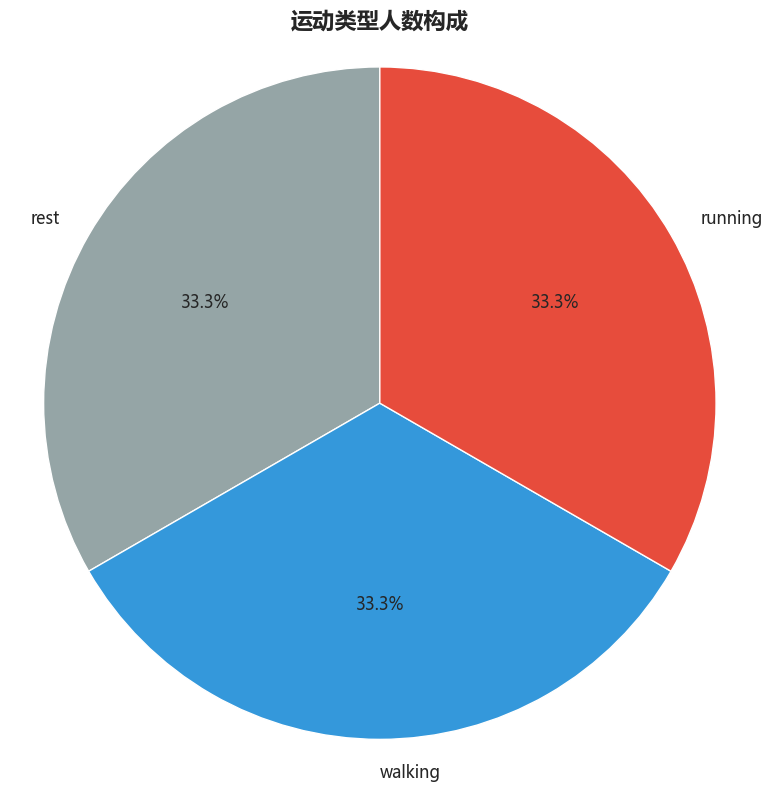

In [2]:
fig, ax = plt.subplots(figsize=(8, 8))

# 统计各运动类型人数
kind_counts = df["kind"].value_counts()

# Matplotlib 一行代码画出饼图
ax.pie(
    kind_counts,
    labels=kind_counts.index,
    autopct="%1.1f%%",     # 自动显示百分比
    colors=["#95A5A6", "#3498DB", "#E74C3C"],
    startangle=90,          # 从 90 度开始（顶部）
    textprops={"fontsize": 12}
)

# Matplotlib 精细美化
ax.set_title("运动类型人数构成", fontsize=16, fontweight="bold", pad=15)

# 保证饼图是圆形
ax.axis("equal")

plt.tight_layout()
plt.show()

## 🍩 3. 环形图：饼图挖空 + 中心文字

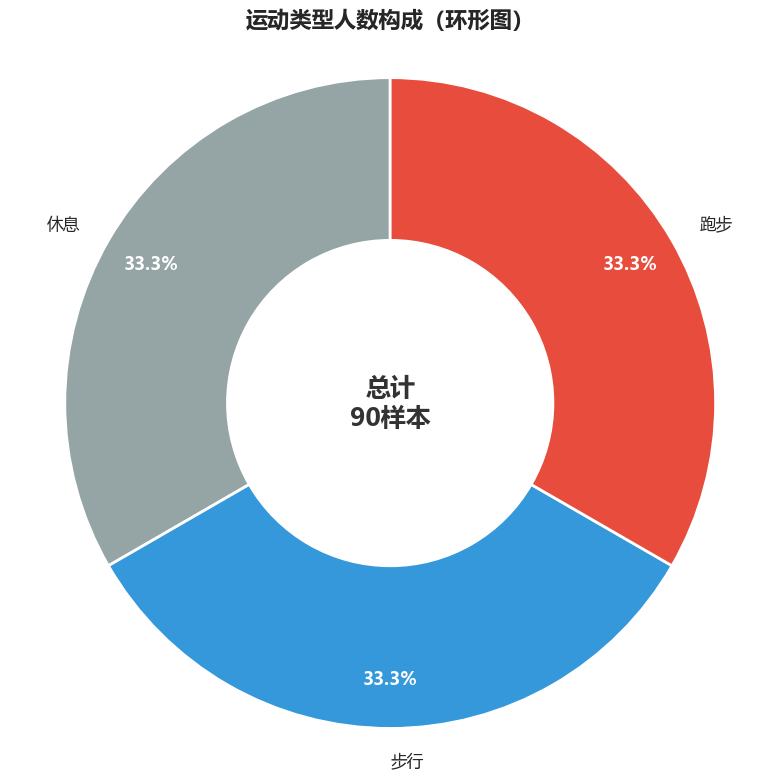

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))

# 统计各运动类型人数
kind_counts = df["kind"].value_counts()

# 绘制环形图（width 控制环的宽度）
wedges, texts, autotexts = ax.pie(
    kind_counts,
    labels=["休息", "步行", "跑步"],
    autopct="%1.1f%%",
    colors=["#95A5A6", "#3498DB", "#E74C3C"],
    startangle=90,
    pctdistance=0.85,       # 百分比标签距离圆心的距离
    textprops={"fontsize": 12},
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2}
)

# 在中心添加圆形白色覆盖，形成环形效果
centre_circle = plt.Circle((0, 0), 0.50, fc="white")
ax.add_artist(centre_circle)

# 在中心显示总样本数
total_samples = len(df)
ax.text(
    0, 0,
    f"总计\n{total_samples}样本",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color="#333333"
)

# 美化百分比标签
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(13)

ax.set_title("运动类型人数构成（环形图）", fontsize=16, fontweight="bold", pad=15)
ax.axis("equal")

plt.tight_layout()
plt.savefig("exercise_kind_donut.png", dpi=150, bbox_inches="tight")
plt.show()

## 📊 4. 堆叠条形图：按运动类型展示饮食方案构成

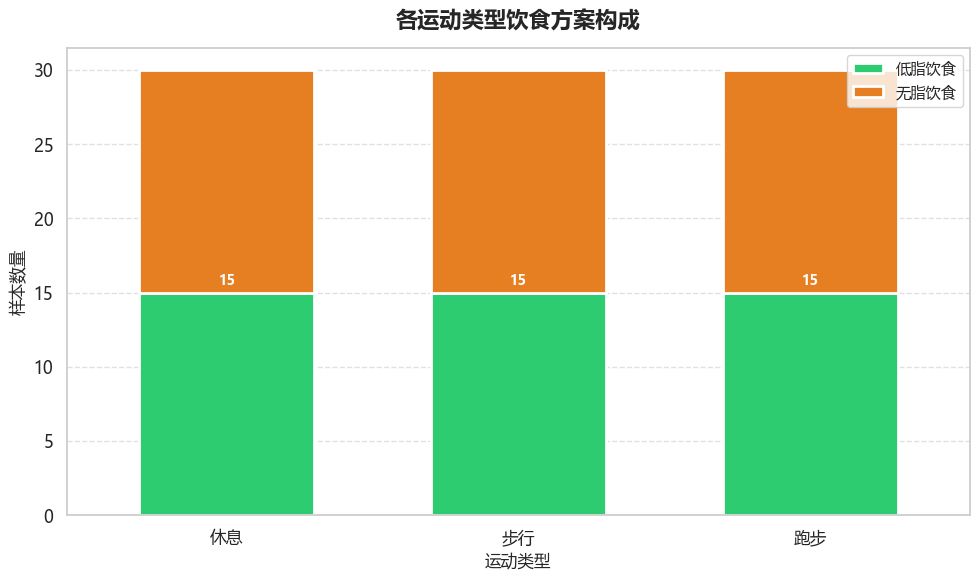

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# 交叉统计：运动类型 × 饮食方案
kind_diet = df.groupby(["kind", "diet"]).size().unstack()

# Pandas 画堆叠条形图（注意：不是 Seaborn）
kind_diet.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#2ECC71", "#E67E22"],
    width=0.6,
    edgecolor="white",
    linewidth=2
)

# Matplotlib 精细美化
ax.set_title("各运动类型饮食方案构成", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("运动类型", fontsize=12)
ax.set_ylabel("样本数量", fontsize=12)
ax.set_xticklabels(["休息", "步行", "跑步"], rotation=0)
ax.legend(["低脂饮食", "无脂饮食"], fontsize=11)

# 添加数值标签
for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=10, padding=3, color="white", fontweight="bold")

ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

## 🎨 5. 高级定制：拉出跑步扇区 + 图例外置

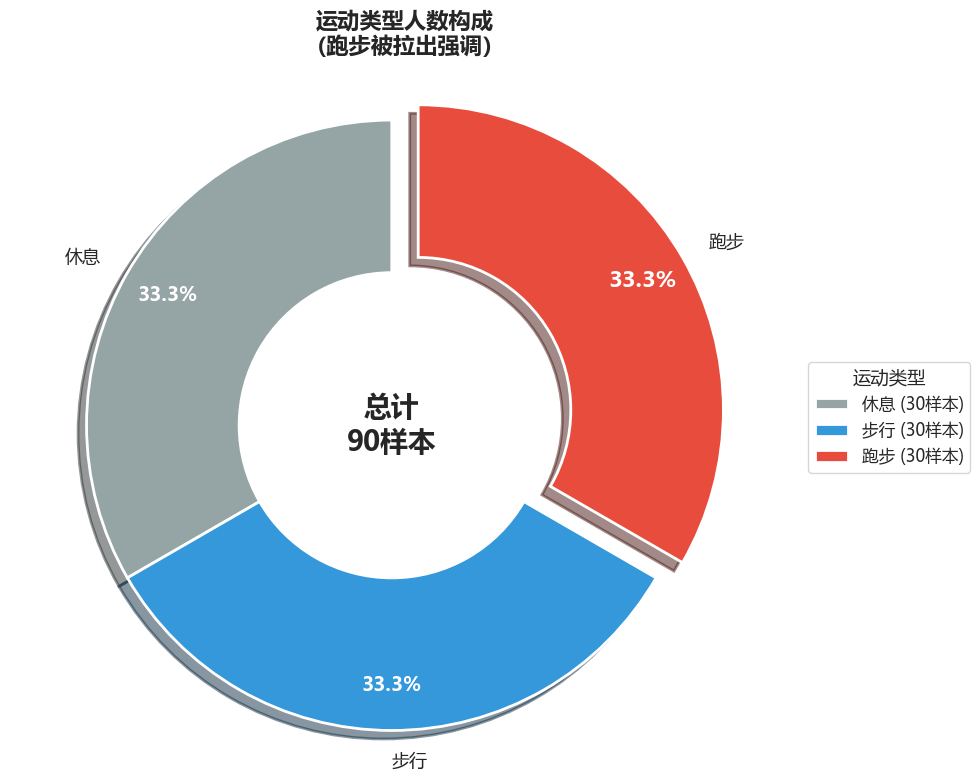

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

kind_counts = df["kind"].value_counts()
explode = (0, 0, 0.1)  # 休息、步行、跑步

wedges, texts, autotexts = ax.pie(
    kind_counts,
    labels=["休息", "步行", "跑步"],
    autopct="%1.1f%%",
    colors=["#95A5A6", "#3498DB", "#E74C3C"],
    startangle=90,
    pctdistance=0.85,
    explode=explode,
    shadow=True,
    textprops={"fontsize": 13},
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2}
)

# 中心圆和文字
centre_circle = plt.Circle((0, 0), 0.50, fc="white")
ax.add_artist(centre_circle)
ax.text(0, 0, f"总计\n{len(df)}样本", ha="center", va="center", fontsize=20, fontweight="bold")

# 美化百分比标签
for i, autotext in enumerate(autotexts):
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(16 if i == 2 else 14)

# 外置图例
ax.legend(
    wedges,
    [f"休息 ({kind_counts.iloc[0]}样本)", f"步行 ({kind_counts.iloc[1]}样本)", f"跑步 ({kind_counts.iloc[2]}样本)"],
    title="运动类型",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12
)

ax.set_title("运动类型人数构成\n（跑步被拉出强调）", fontsize=16, fontweight="bold", pad=15)
ax.axis("equal")

plt.tight_layout()
plt.savefig("exercise_kind_exploded.png", dpi=300, bbox_inches="tight")
plt.show()

## 💾 6. 完整代码模板：高颜值环形图

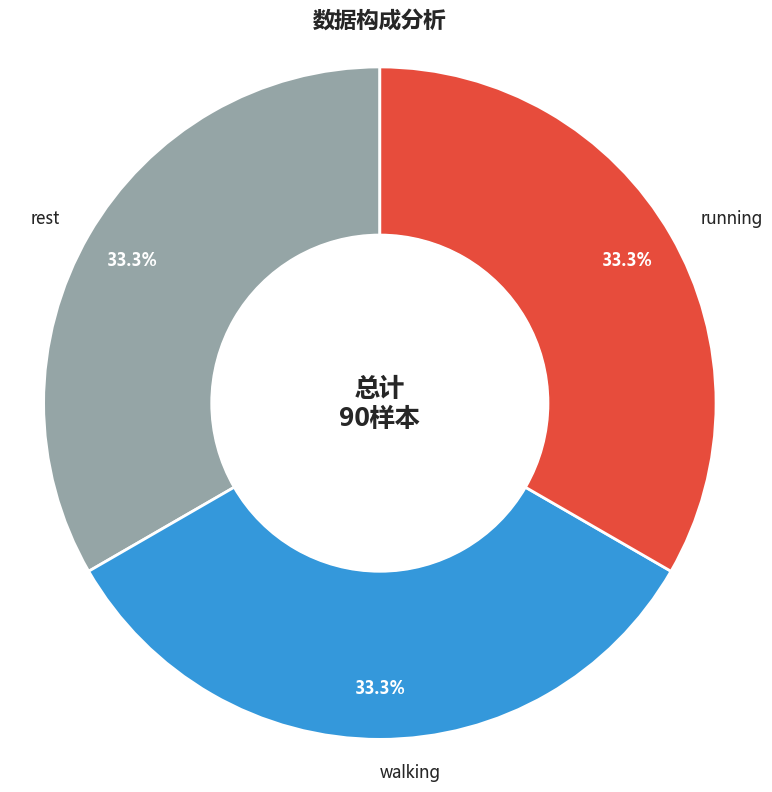

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid", font_scale=1.1,
    rc={"font.sans-serif": ["Microsoft YaHei"],
        "font.family": "sans-serif", "axes.unicode_minus": False}
)

df = sns.load_dataset("exercise")
category_counts = df["kind"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    category_counts, labels=category_counts.index,
    autopct="%1.1f%%", colors=["#95A5A6", "#3498DB", "#E74C3C"],
    startangle=90, pctdistance=0.85, textprops={"fontsize": 12},
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2}
)

centre_circle = plt.Circle((0, 0), 0.50, fc="white")
ax.add_artist(centre_circle)
ax.text(0, 0, f"总计\n{len(df)}样本", ha="center", va="center", fontsize=18, fontweight="bold")

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

ax.set_title("数据构成分析", fontsize=16, fontweight="bold", pad=15)
ax.axis("equal")

plt.tight_layout()
fig.savefig("donut_chart.png", dpi=300, bbox_inches="tight")
plt.show()